# **Group Work Project 2: Derivative Pricing**

## **Team Members**  


### **Sana ur rehman Arain**  
**Location:** Sweden

**Email:** [sanaurrehman01@gmail.com](mailto:sanaurrehman01@gmail.com)  

<br>

*This notebook explores derivative pricing using Monte Carlo simulations under the Heston Stochastic Volatility and Merton Jump-Diffusion models. It covers the model dynamics, parameter settings, Monte Carlo engines, price calculations, Greek computations via finite differences (with common random numbers), and convergence analysis for standard European options. Additionally, it investigates the pricing of American options using the Longstaff–Schwartz method and European barrier options (Up-and-In Call and Down-and-In Put) under these advanced models, including checks for put-call parity and analysis of results for different moneyness levels.*

## **Heston Stochastic Volatility Model**


The **Heston Model** (1993) is a stochastic volatility model that extends the classical Black–Scholes framework by allowing the variance of the asset price to be random and mean-reverting, rather than constant. This makes it more realistic for capturing volatility clustering and the implied volatility smile observed in financial markets.

#### Model Dynamics

The asset price $S_t$ and variance $v_t$ follow the coupled SDEs under the risk-neutral measure:

$$
dS_t = S_t \, (r \, dt + \sqrt{v_t} \, dW_t^S)
$$

$$
dv_t = \kappa (\theta - v_t)\,dt + \sigma_v \sqrt{v_t}\, dW_t^v
$$

with correlation:

$$
dW_t^S \, dW_t^v = \rho \, dt
$$


#### Parameters

* **$S_t$:** Asset price at time $t$
* **$v_t$:** Instantaneous variance of the asset
* **$r$:** Risk-free interest rate
* **$\kappa$:** Speed of mean reversion of the variance
* **$\theta$:** Long-run mean of variance
* **$\sigma_v$:** Volatility of volatility (vol-of-vol)
* **$\rho$:** Correlation between the asset return shocks and variance shocks
* **$W_t^S, W_t^v$:** Two Brownian motions (correlated)

Unlike Black–Scholes, where volatility is fixed, the Heston model assumes volatility fluctuates randomly but tends to revert toward a long-term mean, making it well-suited for option pricing.


In [ ]:
import numpy as np
import pandas as pd
from math import sqrt, exp
import matplotlib.pyplot as plt

In [ ]:
rng = np.random.default_rng(42) # Reproducibility

### Parameters

In [ ]:
# Market / contract
S0, K, r, T = 80.0, 80.0, 0.055, 0.25 # ATM, 3 months maturity

# Heston params
v0, kappa, theta, sigma_v = 0.032, 1.85, 0.045, 0.50  # sigma_v assumed

# MC settings
N_PATHS, N_STEPS = 100_000, 250
DT = T / N_STEPS
DISC = np.exp(-r * T)

# Greeks bump
BUMP_REL = 0.01 # 1% bump for finite-diff Greeks

In [ ]:
# ---- Helpers ----
def std_error(samples):
    return samples.std(ddof=1) / np.sqrt(samples.size)

def call_payoff(ST, K):
    return np.maximum(ST - K, 0.0)

def put_payoff(ST, K):
    return np.maximum(K - ST, 0.0)

In [ ]:
# ---- Random shocks ----
def make_correlated_normals(n_paths, n_steps, rho, rng):
    """Generate correlated normals with correlation rho."""
    eps1 = rng.standard_normal(size=(n_paths, n_steps))
    eps2 = rng.standard_normal(size=(n_paths, n_steps))
    Z1 = eps1
    Z2 = rho * eps1 + np.sqrt(1 - rho**2) * eps2
    return Z1, Z2

In [ ]:
# ---- Heston simulation ----
def heston_terminal_prices(S_init, v0, kappa, theta, sigma_v, r, T, dt, Z1, Z2):
    """Simulate terminal stock prices under Heston (log-Euler for S, full truncation for v)."""
    n_paths, n_steps = Z1.shape
    S = np.full(n_paths, S_init, dtype=np.float64)
    v = np.full(n_paths, v0, dtype=np.float64)
    for t in range(n_steps):
        v_pos = np.maximum(v, 0.0)
        S *= np.exp((r - 0.5 * v_pos) * dt + np.sqrt(v_pos * dt) * Z1[:, t])
        v += kappa * (theta - v_pos) * dt + sigma_v * np.sqrt(v_pos * dt) * Z2[:, t]
    return S

In [ ]:
# ---- Pricing ----
def heston_price_mc(S_init, K, r, T, v0, kappa, theta, sigma_v, rho,
                    n_paths=N_PATHS, n_steps=N_STEPS, rng=rng, payoff_fn=call_payoff):

    if n_paths is None:
        n_paths = N_PATHS
    if n_steps is None:
        n_steps = N_STEPS
    if rng is None:
        rng = np.random.default_rng(42)

    Z1, Z2 = make_correlated_normals(n_paths, n_steps, rho, rng)
    ST = heston_terminal_prices(S_init, v0, kappa, theta, sigma_v, r, T, T/n_steps, Z1, Z2)
    payoff = payoff_fn(ST, K)
    price = np.exp(-r * T) * payoff.mean()
    se = np.exp(-r * T) * std_error(payoff)
    return price, se, (Z1, Z2)

In [ ]:
# ---- Greeks ----
def greeks_delta_gamma(S0, K, r, T, v0, kappa, theta, sigma_v, rho, payoff_fn, bump_rel=BUMP_REL, Z1=None, Z2=None):
    """Central finite-difference Greeks with CRN."""
    h = bump_rel * S0
    if Z1 is None or Z2 is None:
        Z1, Z2 = make_correlated_normals(N_PATHS, N_STEPS, rho, rng)
    ST_up = heston_terminal_prices(S0 + h, v0, kappa, theta, sigma_v, r, T, DT, Z1, Z2)
    ST_dn = heston_terminal_prices(S0 - h, v0, kappa, theta, sigma_v, r, T, DT, Z1, Z2)
    P_up = np.exp(-r * T) * payoff_fn(ST_up, K).mean()
    P_dn = np.exp(-r * T) * payoff_fn(ST_dn, K).mean()
    ST_0 = heston_terminal_prices(S0, v0, kappa, theta, sigma_v, r, T, DT, Z1, Z2)
    P_0 = np.exp(-r * T) * payoff_fn(ST_0, K).mean()
    delta = (P_up - P_dn) / (2 * h)
    gamma = (P_up - 2 * P_0 + P_dn) / (h**2)
    return delta, gamma

### Results for Q5 & Q6

In [ ]:
# ---- Main runner ----
def run_cases():
    rows = []
    for q, rho in [(5, -0.30), (6, -0.70)]:
        call_price, call_se, (Z1, Z2) = heston_price_mc(S0, K, r, T, v0, kappa, theta, sigma_v, rho, payoff_fn=call_payoff)
        call_delta, call_gamma = greeks_delta_gamma(S0, K, r, T, v0, kappa, theta, sigma_v, rho, call_payoff, Z1=Z1, Z2=Z2)
        put_price, put_se, _ = heston_price_mc(S0, K, r, T, v0, kappa, theta, sigma_v, rho, payoff_fn=put_payoff)
        put_delta, put_gamma = greeks_delta_gamma(S0, K, r, T, v0, kappa, theta, sigma_v, rho, put_payoff, Z1=Z1, Z2=Z2)
        rows.append([q, "Heston", rho, "ATM Call", call_price, call_se, call_delta, call_gamma])
        rows.append([q, "Heston", rho, "ATM Put",  put_price,  put_se,  put_delta,  put_gamma])
    return pd.DataFrame(rows, columns=["Question","Model","rho","Option","Price","StdErr","Delta","Gamma"])

In [ ]:
if __name__ == "__main__":
    df = run_cases()
    print(df.round(6))

   Question   Model  rho    Option     Price    StdErr     Delta     Gamma
0         5  Heston -0.3  ATM Call  3.414703  0.014481  0.617761  0.058446
1         5  Heston -0.3   ATM Put  2.316691  0.013087 -0.382356  0.058446
2         6  Heston -0.7  ATM Call  3.433214  0.012328  0.656913  0.050695
3         6  Heston -0.7   ATM Put  2.347915  0.014277 -0.342986  0.050695


### Sample Paths

In [ ]:
def simulate_paths_full(S_init, v0, kappa, theta, sigma_v, r, T, n_steps, n_paths, rho, rng):
    dt = T / n_steps
    S = np.full((n_paths, n_steps+1), S_init)
    v = np.full((n_paths, n_steps+1), v0)
    Z1, Z2 = make_correlated_normals(n_paths, n_steps, rho, rng)
    for t in range(n_steps):
        v_pos = np.maximum(v[:, t], 0.0)
        S[:, t+1] = S[:, t] * np.exp((r - 0.5 * v_pos) * dt + np.sqrt(v_pos * dt) * Z1[:, t])
        v[:, t+1] = v[:, t] + kappa * (theta - v_pos) * dt + sigma_v * np.sqrt(v_pos * dt) * Z2[:, t]
    return S, v

In [ ]:
S_paths, v_paths = simulate_paths_full(S0, v0, kappa, theta, sigma_v, r, T, 200, 8, -0.30, rng)
time_grid = np.linspace(0.0, T, S_paths.shape[1])

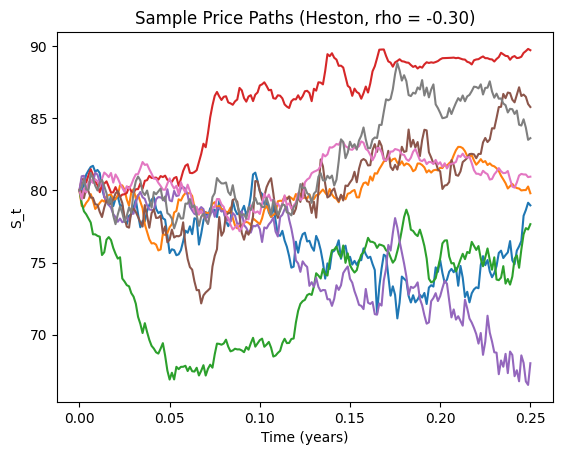

In [ ]:
plt.figure()
for i in range(S_paths.shape[0]):
    plt.plot(time_grid, S_paths[i])
plt.title("Sample Price Paths (Heston, rho = -0.30)")
plt.xlabel("Time (years)")
plt.ylabel("S_t")
plt.show()

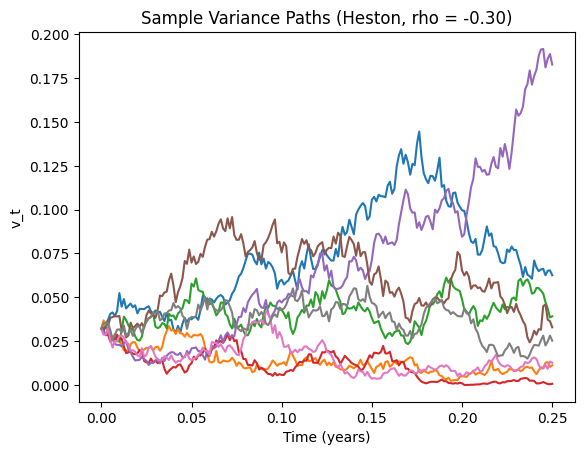

In [ ]:
plt.figure()
for i in range(v_paths.shape[0]):
    plt.plot(time_grid, np.maximum(v_paths[i], 0.0))
plt.title("Sample Variance Paths (Heston, rho = -0.30)")
plt.xlabel("Time (years)")
plt.ylabel("v_t")
plt.show()

### Monte Carlo Convergence

In [ ]:
def mc_convergence_call(S0, K, r, T, v0, kappa, theta, sigma_v, rho, max_paths=20_000, step=500):
    steps = np.arange(step, max_paths + 1, step)
    means = []
    Z1, Z2 = make_correlated_normals(max_paths, N_STEPS, rho, rng)
    for n in steps:
        ST = heston_terminal_prices(S0, v0, kappa, theta, sigma_v, r, T, DT, Z1[:n], Z2[:n])
        price = np.exp(-r * T) * call_payoff(ST, K).mean()
        means.append(price)
    return steps, np.array(means)

In [ ]:
steps, means = mc_convergence_call(S0, K, r, T, v0, kappa, theta, sigma_v, -0.30)

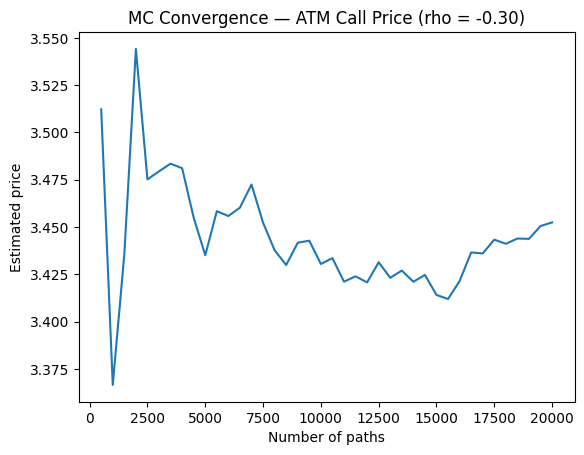

In [ ]:
plt.figure()
plt.plot(steps, means)
plt.title("MC Convergence — ATM Call Price (rho = -0.30)")
plt.xlabel("Number of paths")
plt.ylabel("Estimated price")
plt.show()

This convergence plot shows how the Monte Carlo estimate of the ATM European call price under the Heston model ($\rho=-0.30$) stabilizes as the number of simulated paths increases. At low path counts (under \~2,000), the estimates fluctuate widely due to high variance, ranging between 3.37 and 3.55. As more paths are added, the variance narrows, and by around 15,000–20,000 paths, the price settles near 3.42, demonstrating convergence toward the true option value in line with the Law of Large Numbers.

## **Merton Jump-Diffusion Model**

The **Merton Jump-Diffusion Model** (1976) extends the classical **Black–Scholes model** by incorporating sudden and discontinuous movements (jumps) in asset prices, in addition to the usual continuous diffusion process. This makes it more realistic for capturing market phenomena such as crashes, large announcements, or unexpected events.

#### Model Dynamics

The asset price $S_t$ under the Merton jump-diffusion model evolves as:

$$
dS_t = S_t \left( \mu \, dt + \sigma \, dW_t \right) + S_t \, dJ_t
$$

where

$$
J_t = \sum_{i=1}^{N_t} (Y_i - 1)
$$

and $N_t$ is a **Poisson process** with intensity $\lambda$.

Equivalently, the log-price dynamics are:

$$
d \ln S_t = \left( \mu - \frac{1}{2}\sigma^2 - \lambda k \right) dt + \sigma \, dW_t + \sum_{i=1}^{N_t} \ln Y_i
$$

#### Parameters

* $S_t$: Asset price at time $t$
* $\mu$: Drift term (expected rate of return)
* $\sigma$: Volatility of the continuous part (diffusion)
* $W_t$: Standard Brownian motion
* $N_t$: Poisson process with rate $\lambda$ (average number of jumps per unit time)
* $Y_i$: Random jump size (typically lognormally distributed)
* $\lambda$: Jump intensity (frequency of jumps)
* $k = \mathbb{E}[Y - 1]$: Mean percentage jump size adjustment


The **key idea** is that price changes are driven by both **continuous small fluctuations** (Brownian motion) and **occasional large jumps** (Poisson-driven).




In [ ]:
# -------------------
# Parameters
# -------------------
sigma = 0.35   # Diffusion volatility

# Merton jump parameters
mu_J = -0.5    # Mean of log jump size
delta_J = 0.22 # Volatility of log jump size

# Simulation settings
N_PATHS = 100_000
N_STEPS = 250
dt = T / N_STEPS

rng = np.random.default_rng(42)  # For reproducibility

# -------------------
# Monte Carlo engine
# -------------------
def simulate_merton_paths(S0, r, sigma, T, N_PATHS, N_STEPS, lamb, mu_J, delta_J, rng):
    dt = T / N_STEPS
    S = np.full((N_PATHS,), S0, dtype=np.float64)

    # compensator (to ensure martingale property)
    rj = lamb * (np.exp(mu_J + 0.5 * delta_J**2) - 1)

    for _ in range(N_STEPS):
        Z1 = rng.standard_normal(N_PATHS)
        Z2 = rng.standard_normal(N_PATHS)
        # Number of jumps in each path during dt
        Y = rng.poisson(lamb * dt, N_PATHS)

        jump_component = (np.exp(mu_J + delta_J * Z2) - 1.0) * Y
        diffusion_component = np.exp((r - rj - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z1)

        S = S * (diffusion_component + jump_component)
        S = np.maximum(S, 1e-8)  # prevent numerical blow-up

    return S

# -------------------
# Payoff functions
# -------------------
def call_payoff(ST, K):
    return np.maximum(ST - K, 0.0)

def put_payoff(ST, K):
    return np.maximum(K - ST, 0.0)

def price_option_mc(S0, K, r, T, sigma, lamb, mu_J, delta_J, N_PATHS, N_STEPS, payoff_fn, rng):
    ST = simulate_merton_paths(S0, r, sigma, T, N_PATHS, N_STEPS, lamb, mu_J, delta_J, rng)
    payoff = payoff_fn(ST, K)
    return np.exp(-r * T) * payoff.mean()

# -------------------
# Run experiments
# -------------------
for lamb in [0.75, 0.25]:
    call_price = price_option_mc(S0, K, r, T, sigma, lamb, mu_J, delta_J, N_PATHS, N_STEPS, call_payoff, rng)
    put_price  = price_option_mc(S0, K, r, T, sigma, lamb, mu_J, delta_J, N_PATHS, N_STEPS, put_payoff, rng)

    print(f"λ = {lamb:.2f}")
    print(f"  European Call (ATM): {call_price:.4f}")
    print(f"  European Put  (ATM): {put_price:.4f}\n")


λ = 0.75
  European Call (ATM): 8.3356
  European Put  (ATM): 7.2623

λ = 0.25
  European Call (ATM): 6.8926
  European Put  (ATM): 5.7935



In [ ]:
# ---- Greeks for Merton ----
def greeks_delta_gamma_merton(S0, K, r, T, sigma, lamb, mu_J, delta_J,
                              N_PATHS, N_STEPS, payoff_fn, bump_rel=0.01, rng=None):
    """
    Central finite-difference Greeks with common random numbers (CRN).
    bump_rel = relative bump size (e.g. 1% of S0).
    """
    if rng is None:
        rng = np.random.default_rng(123)
    h = bump_rel * S0

    # Generate random numbers once (CRN)
    Z1 = rng.standard_normal((N_STEPS, N_PATHS))
    Z2 = rng.standard_normal((N_STEPS, N_PATHS))
    Y  = rng.poisson(lamb * T / N_STEPS, size=(N_STEPS, N_PATHS))

    def terminal_prices(S_init):
        S = np.full(N_PATHS, S_init, dtype=np.float64)
        rj = lamb * (np.exp(mu_J + 0.5 * delta_J**2) - 1)
        for t in range(N_STEPS):
            jump_component = (np.exp(mu_J + delta_J * Z2[t]) - 1.0) * Y[t]
            diffusion_component = np.exp((r - rj - 0.5 * sigma**2) * (T/N_STEPS)
                                         + sigma * np.sqrt(T/N_STEPS) * Z1[t])
            S *= (diffusion_component + jump_component)
            S = np.maximum(S, 1e-8)
        return S

    # Prices for bumped and base spots
    ST_up = terminal_prices(S0 + h)
    ST_dn = terminal_prices(S0 - h)
    ST_0  = terminal_prices(S0)

    P_up = np.exp(-r * T) * payoff_fn(ST_up, K).mean()
    P_dn = np.exp(-r * T) * payoff_fn(ST_dn, K).mean()
    P_0  = np.exp(-r * T) * payoff_fn(ST_0, K).mean()

    delta = (P_up - P_dn) / (2*h)
    gamma = (P_up - 2*P_0 + P_dn) / (h**2)

    return delta, gamma


In [ ]:
for lamb in [0.75, 0.25]:
    call_delta, call_gamma = greeks_delta_gamma_merton(S0, K, r, T, sigma,
                                                       lamb, mu_J, delta_J,
                                                       N_PATHS, N_STEPS,
                                                       call_payoff, rng=rng)
    put_delta, put_gamma  = greeks_delta_gamma_merton(S0, K, r, T, sigma,
                                                      lamb, mu_J, delta_J,
                                                      N_PATHS, N_STEPS,
                                                      put_payoff, rng=rng)

    print(f"λ = {lamb:.2f}")
    print(f"  Call Δ = {call_delta:.4f}, Γ = {call_gamma:.6f}")
    print(f"  Put  Δ = {put_delta:.4f}, Γ = {put_gamma:.6f}\n")



λ = 0.75
  Call Δ = 0.6492, Γ = 0.022481
  Put  Δ = -0.3519, Γ = 0.022219

λ = 0.25
  Call Δ = 0.5982, Γ = 0.026590
  Put  Δ = -0.4023, Γ = 0.025832



In [ ]:
def simulate_merton_paths_full(S0, r, sigma, T, N_PATHS, N_STEPS, lamb, mu_J, delta_J, rng):
    dt = T / N_STEPS
    S = np.full((N_PATHS, N_STEPS + 1), S0, dtype=np.float64)

    # compensator (martingale correction)
    rj = lamb * (np.exp(mu_J + 0.5 * delta_J**2) - 1)

    for t in range(1, N_STEPS + 1):
        Z1 = rng.standard_normal(N_PATHS)
        Z2 = rng.standard_normal(N_PATHS)
        Y = rng.poisson(lamb * dt, N_PATHS)

        jump_component = (np.exp(mu_J + delta_J * Z2) - 1.0) * Y
        diffusion_component = np.exp((r - rj - 0.5 * sigma**2) * dt
                                     + sigma * np.sqrt(dt) * Z1)

        S[:, t] = S[:, t-1] * (diffusion_component + jump_component)
        S[:, t] = np.maximum(S[:, t], 1e-8)
    return S

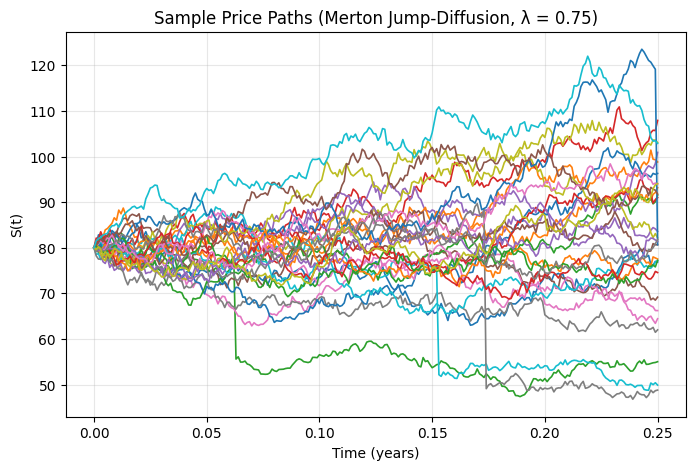

In [ ]:
N_PATHS_SAMPLE = 30

S_paths = simulate_merton_paths_full(S0, r, sigma, T,
                                     N_PATHS_SAMPLE, N_STEPS,
                                     lamb=0.75, mu_J=mu_J, delta_J=delta_J,
                                     rng=rng)

time_grid = np.linspace(0, T, N_STEPS + 1)

plt.figure(figsize=(8,5))
for i in range(N_PATHS_SAMPLE):
    plt.plot(time_grid, S_paths[i], lw=1.2)
plt.title("Sample Price Paths (Merton Jump-Diffusion, λ = 0.75)")
plt.xlabel("Time (years)")
plt.ylabel("S(t)")
plt.grid(True, alpha=0.3)
plt.show()


### Monte Carlo Convergence

In [ ]:
rng = np.random.default_rng(42)

def mc_convergence_call_merton(S0, K, r, T, sigma, lamb, mu_J, delta_J, max_paths=20_000, step=500):
    steps = np.arange(step, max_paths + 1, step)
    means = []
    dt = T / N_STEPS

    # Pre-generate random numbers
    Z1 = rng.standard_normal((max_paths, N_STEPS))
    Z2 = rng.standard_normal((max_paths, N_STEPS))
    Y  = rng.poisson(lamb * dt, size=(max_paths, N_STEPS))

    # compensator
    rj = lamb * (np.exp(mu_J + 0.5 * delta_J**2) - 1)

    for n in steps:
        S = np.full(n, S0, dtype=np.float64)
        for t in range(N_STEPS):
            jump_component = (np.exp(mu_J + delta_J * Z2[:n, t]) - 1.0) * Y[:n, t]
            diffusion_component = np.exp((r - rj - 0.5 * sigma**2) * dt
                                         + sigma * np.sqrt(dt) * Z1[:n, t])
            S *= (diffusion_component + jump_component)
            S = np.maximum(S, 1e-8)
        payoff = call_payoff(S, K)
        price = np.exp(-r * T) * payoff.mean()
        means.append(price)

    return steps, np.array(means)

In [ ]:
# ---- Run for λ = 0.75 ----
steps, means = mc_convergence_call_merton(S0, K, r, T, sigma,
                                          lamb=0.75, mu_J=mu_J, delta_J=delta_J,
                                          max_paths=20_000, step=500)

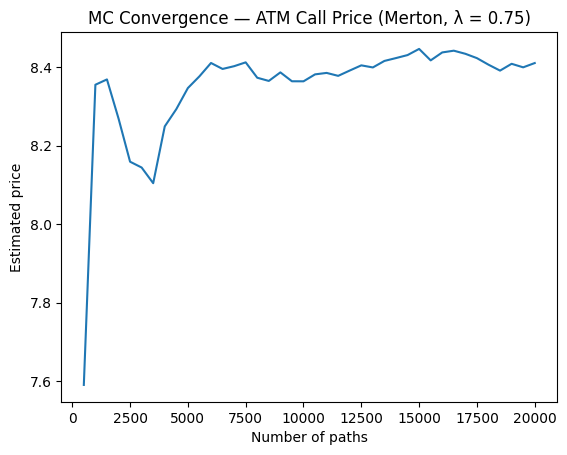

In [ ]:
plt.figure()
plt.plot(steps, means)
plt.title("MC Convergence — ATM Call Price (Merton, λ = 0.75)")
plt.xlabel("Number of paths")
plt.ylabel("Estimated price")
plt.show()

## Put-Call Parity Check

In [ ]:
def check_put_call_parity(call_price, put_price, S0, K, r, T):
    lhs = call_price - put_price
    rhs = S0 - K * np.exp(-r * T)
    diff = lhs - rhs
    return lhs, rhs, diff

In [ ]:
DT = T / N_STEPS

def parity_heston(rho):
    # same paths for call & put (tight parity)
    Z1, Z2 = make_correlated_normals(N_PATHS, N_STEPS, rho, rng)
    ST = heston_terminal_prices(S0, v0, kappa, theta, sigma_v, r, T, DT, Z1, Z2)
    disc = np.exp(-r * T)

    call_price = disc * np.maximum(ST - K, 0.0).mean()
    put_price  = disc * np.maximum(K - ST, 0.0).mean()

    lhs, rhs, diff = check_put_call_parity(call_price, put_price, S0, K, r, T)
    print(f"ρ={rho:+.2f} | Call={call_price:.6f}  Put={put_price:.6f}  "
          f"(C-P)={lhs:.6f}  RHS={rhs:.6f}  Diff={diff:.6f}")

# Run both cases
for rho in (-0.30, -0.70):
    parity_heston(rho)

ρ=-0.30 | Call=3.435389  Put=2.325544  (C-P)=1.109844  RHS=1.092472  Diff=0.017372
ρ=-0.70 | Call=3.463814  Put=2.323161  (C-P)=1.140653  RHS=1.092472  Diff=0.048181


In [ ]:
# -------------------
# Run parity check for Merton Model
# -------------------
for lamb in [0.75, 0.25]:
    call_price = price_option_mc(S0, K, r, T, sigma, lamb, mu_J, delta_J, N_PATHS, N_STEPS, call_payoff, rng)
    put_price  = price_option_mc(S0, K, r, T, sigma, lamb, mu_J, delta_J, N_PATHS, N_STEPS, put_payoff, rng)

    lhs, rhs, diff = check_put_call_parity(call_price, put_price, S0, K, r, T)

    print(f"λ = {lamb:.2f}")
    print(f"  Call: {call_price:.4f}, Put: {put_price:.4f}")
    print(f"  LHS (C - P) = {lhs:.4f}")
    print(f"  RHS (S0 - K e^(-rT)) = {rhs:.4f}")
    print(f"  Difference (LHS - RHS) = {diff:.6f}\n")

λ = 0.75
  Call: 8.2859, Put: 7.2433
  LHS (C - P) = 1.0427
  RHS (S0 - K e^(-rT)) = 1.0925
  Difference (LHS - RHS) = -0.049818

λ = 0.25
  Call: 6.8341, Put: 5.7073
  LHS (C - P) = 1.1267
  RHS (S0 - K e^(-rT)) = 1.0925
  Difference (LHS - RHS) = 0.034262



### Heston Model for Different Moneyness Levels

In [ ]:
# 7 moneyness levels (S/K). Strike = S0 / m
moneyness_list = [0.85, 0.90, 0.95, 1.00, 1.05, 1.10, 1.15]
strikes = [S0 / m for m in moneyness_list]

rows = []
for rho in (-0.30, -0.70):
    for m, K_i in zip(moneyness_list, strikes):
        call_price, call_se, _ = heston_price_mc(
            S0, K_i, r, T, v0, kappa, theta, sigma_v, rho, payoff_fn=call_payoff
        )
        put_price, put_se, _ = heston_price_mc(
            S0, K_i, r, T, v0, kappa, theta, sigma_v, rho, payoff_fn=put_payoff
        )
        rows.append({
            "rho": rho,
            "moneyness (S/K)": m,
            "Strike K": K_i,
            "Call Price": call_price,
            "SE(Call)": call_se,
            "Put Price": put_price,
            "SE(Put)": put_se
        })

heston_strikes_df = pd.DataFrame(rows).sort_values(["rho","moneyness (S/K)"]).reset_index(drop=True)
heston_strikes_df


,rho,moneyness (S/K),Strike K,Call Price,SE(Call),Put Price,SE(Put)
0,-0.7,0.85,94.117647,0.031525,0.001213,12.846667,0.022464
1,-0.7,0.90,88.888889,0.279039,0.003549,7.966898,0.021514
2,-0.7,0.95,84.210526,1.344076,0.007781,4.405557,0.018393
3,-0.7,1.00,80.000000,3.443129,0.012344,2.353113,0.014294
4,-0.7,1.05,76.190476,6.102553,0.015871,1.248794,0.010581
5,-0.7,1.10,72.727273,8.948432,0.018382,0.685920,0.007792
6,-0.7,1.15,69.565217,11.725694,0.019978,0.361631,0.005593
7,-0.3,0.85,94.117647,0.142194,0.003305,12.962616,0.022167
8,-0.3,0.90,88.888889,0.520692,0.006223,8.210441,0.020379
9,-0.3,0.95,84.210526,1.517559,0.010350,4.568023,0.017175


### Merton Pricing for Different Moneyness Levels

In [ ]:
# 7 moneyness levels (S/K). Strike = S0 / m
moneyness_list = [0.85, 0.90, 0.95, 1.00, 1.05, 1.10, 1.15]
strikes = [S0 / m for m in moneyness_list]

rows = []
for lamb in (0.75, 0.25):
    for m, K_i in zip(moneyness_list, strikes):
        # calls and puts using your price_option_mc (Merton)
        call_price = price_option_mc(S0, K_i, r, T, sigma,
                                     lamb, mu_J, delta_J,
                                     N_PATHS, N_STEPS, call_payoff, rng)
        put_price  = price_option_mc(S0, K_i, r, T, sigma,
                                     lamb, mu_J, delta_J,
                                     N_PATHS, N_STEPS, put_payoff, rng)
        rows.append({
            "lambda": lamb,
            "moneyness (S/K)": m,
            "Strike K": K_i,
            "Call Price": call_price,
            "Put Price": put_price
        })

merton_strikes_df = pd.DataFrame(rows).sort_values(["lambda","moneyness (S/K)"]).reset_index(drop=True)

# (optional) Put–call parity difference column
merton_strikes_df["Parity Diff"] = (
    merton_strikes_df["Call Price"] - merton_strikes_df["Put Price"]
    - (S0 - merton_strikes_df["Strike K"] * np.exp(-r*T))
)

merton_strikes_df


,lambda,moneyness (S/K),Strike K,Call Price,Put Price,Parity Diff
0,0.25,0.85,94.117647,1.999357,14.940384,-0.108641
1,0.25,0.90,88.888889,3.272782,10.915787,0.032025
2,0.25,0.95,84.210526,4.920121,7.953764,0.026912
3,0.25,1.00,80.000000,6.844956,5.688871,0.063613
4,0.25,1.05,76.190476,8.954073,4.119557,-0.015457
5,0.25,1.10,72.727273,11.226874,2.984065,-0.023075
6,0.25,1.15,69.565217,13.561562,2.222342,-0.045538
7,0.75,0.85,94.117647,2.776600,15.641993,-0.033007
8,0.75,0.90,88.888889,4.372947,12.038781,0.009197
9,0.75,0.95,84.210526,6.238107,9.171171,0.127491


### Longstaff–Schwartz (LSM) for American Call
  - Basis: polynomials [1, S, S^2]
  - Backward induction on in-the-money paths

The **Longstaff–Schwartz Model** (2001) is a numerical method for pricing American-style options.

The key idea is to use Monte Carlo simulation to generate possible paths of the underlying asset, and then apply least-squares regression to estimate the continuation value at each exercise date. This determines whether early exercise is optimal.


#### Algorithm Outline

1. Simulate $M$ paths of the underlying asset $S_t$ using a chosen stochastic model (e.g., Black–Scholes, Heston, Merton).

2. Work backwards in time from maturity $T$.

3. At each potential exercise date $t$, for all in-the-money paths:

   * Estimate the **continuation value** (expected discounted payoff if not exercised) using a regression:

   $$
   C_t \approx \mathbb{E}\big[ e^{-r \Delta t} V_{t+\Delta t} \,\big|\, S_t \big]
   $$

   where $V_{t+\Delta t}$ is the future option value.

   * Compare immediate exercise payoff vs. continuation value:

   $$
   V_t = \max\big( \text{Payoff}(S_t), \; C_t \big)
   $$

4. Discount the optimal payoffs back to time $0$ and average across all paths to obtain the option price.

#### Parameters and Notation

* $S_t$: Asset price at time $t$
* $r$: Risk-free interest rate
* $T$: Maturity of the option
* $\Delta t$: Time step between simulation points
* $V_t$: Option value at time $t$
* $C_t$: Continuation value (expected value of holding the option)
* $\text{Payoff}(S_t)$: Immediate payoff if exercised at time $t$

The key idea is that the Longstaff–Schwartz method combines simulation with regression-based estimation of continuation values, making it one of the most popular and practical approaches for valuing American options.


In [ ]:
# ---- American Call (Heston, LSM) for rho = -0.30 ----
def american_call_heston_lsm(S0, K, r, T, v0, kappa, theta, sigma_v, rho=-0.30,
                             n_paths=N_PATHS, n_steps=N_STEPS, rng=rng):
    dt = T / n_steps
    df = np.exp(-r * dt)

    # Reuse your path simulator (Heston)
    S_paths, _ = simulate_paths_full(S0, v0, kappa, theta, sigma_v, r, T,
                                     n_steps, n_paths, rho, rng)  # shape: (n_paths, n_steps+1)

    # Payoffs & bookkeeping
    payoff = np.maximum(S_paths - K, 0.0)          # (n_paths, n_steps+1)
    cashflow = payoff[:, -1].copy()                # start with maturity payoff
    exercise_time = np.full(n_paths, n_steps, int) # all exercise at maturity initially

    # Backward induction (t = n_steps-1 ... 1)
    for t in range(n_steps - 1, 0, -1):
        S_t = S_paths[:, t]
        itm = S_t > K                              # in-the-money paths at time t
        if not np.any(itm):
            continue

        # Continuation value via linear regression on basis [1, S, S^2]
        X = np.column_stack([np.ones(itm.sum()), S_t[itm], S_t[itm]**2])
        Y = cashflow[itm] * (df ** (exercise_time[itm] - t))  # value at time t
        coeffs, *_ = np.linalg.lstsq(X, Y, rcond=None)
        continuation = coeffs[0] + coeffs[1]*S_t + coeffs[2]*S_t**2

        # Exercise decision
        exercise = (itm) & (payoff[:, t] >= continuation)
        cashflow[exercise] = payoff[exercise, t]
        exercise_time[exercise] = t

    # Present value
    american_call_price = np.mean(cashflow * (df ** exercise_time))
    return american_call_price



In [ ]:
# ---- Run (rho = -0.30) and compare to European call ----
rho = -0.30
amer_call = american_call_heston_lsm(S0, K, r, T, v0, kappa, theta, sigma_v, rho)

euro_call, euro_call_se, _ = heston_price_mc(
    S0, K, r, T, v0, kappa, theta, sigma_v, rho, payoff_fn=call_payoff
)

print(f"American Call (Heston, ρ={rho:+.2f}): {amer_call:.4f}")
print(f"European Call (Heston, ρ={rho:+.2f}): {euro_call:.4f}  (± {1.96*euro_call_se:.4f})")

American Call (Heston, ρ=-0.30): 3.3642
European Call (Heston, ρ=-0.30): 3.3966  (± 0.0282)


With no dividends, the American call is very close to the European call (early exercise is typically sub-optimal).

### Computing Greeks for American Call

In [ ]:
# --- use same step/paths and RNG as your notebook ---
DT = T / N_STEPS
rho = -0.30

# Make shocks once (CRN)
Z1_crn, Z2_crn = make_correlated_normals(N_PATHS, N_STEPS, rho, rng)

In [ ]:
def simulate_paths_full_with_shocks(S_init, v0, kappa, theta, sigma_v, r, T, Z1, Z2):
    """Same as simulate_paths_full, but uses provided Z1,Z2 (for CRN)."""
    n_paths, n_steps = Z1.shape
    dt = T / n_steps
    S = np.full((n_paths, n_steps+1), S_init, dtype=np.float64)
    v = np.full((n_paths, n_steps+1), v0, dtype=np.float64)
    for t in range(n_steps):
        v_pos = np.maximum(v[:, t], 0.0)
        S[:, t+1] = S[:, t] * np.exp((r - 0.5 * v_pos) * dt + np.sqrt(v_pos * dt) * Z1[:, t])
        v[:, t+1] = v[:, t] + kappa * (theta - v_pos) * dt + sigma_v * np.sqrt(v_pos * dt) * Z2[:, t]
    return S, v


In [ ]:
def american_call_heston_lsm_from_shocks(S_init, K, r, T, v0, kappa, theta, sigma_v, Z1, Z2):
    """LSM American call using given shocks (so base/up/down share the same paths)."""
    n_steps = Z1.shape[1]
    dt = T / n_steps
    df = np.exp(-r * dt)

    S_paths, _ = simulate_paths_full_with_shocks(S_init, v0, kappa, theta, sigma_v, r, T, Z1, Z2)
    payoff = np.maximum(S_paths - K, 0.0)
    cashflow = payoff[:, -1].copy()
    exercise_time = np.full(S_paths.shape[0], n_steps, int)

    for t in range(n_steps - 1, 0, -1):
        S_t = S_paths[:, t]
        itm = S_t > K
        if not np.any(itm):
            continue
        X = np.column_stack([np.ones(itm.sum()), S_t[itm], S_t[itm]**2])
        Y = cashflow[itm] * (df ** (exercise_time[itm] - t))
        beta, *_ = np.linalg.lstsq(X, Y, rcond=None)
        continuation = beta[0] + beta[1]*S_t + beta[2]*S_t**2
        exercise = itm & (payoff[:, t] >= continuation)
        cashflow[exercise] = payoff[exercise, t]
        exercise_time[exercise] = t

    return np.mean(cashflow * (df ** exercise_time))

In [ ]:
# --- Price + Greeks (central differences with CRN) ---
h = 0.01 * S0  # 1% bump
A_dn = american_call_heston_lsm_from_shocks(S0 - h, K, r, T, v0, kappa, theta, sigma_v, Z1_crn, Z2_crn)
A_0  = american_call_heston_lsm_from_shocks(S0,     K, r, T, v0, kappa, theta, sigma_v, Z1_crn, Z2_crn)
A_up = american_call_heston_lsm_from_shocks(S0 + h, K, r, T, v0, kappa, theta, sigma_v, Z1_crn, Z2_crn)

Delta_A = (A_up - A_dn) / (2*h)
Gamma_A = (A_up - 2*A_0 + A_dn) / (h**2)

print(f"American Call (Heston, ρ={rho:+.2f}): {A_0:.6f}")
print(f"  Δ ≈ {Delta_A:.6f}   Γ ≈ {Gamma_A:.6f}")

American Call (Heston, ρ=-0.30): 3.375849
  Δ ≈ 0.612071   Γ ≈ 0.072028


### European CUI using Heston

In [ ]:
# Inputs for this task
K_barrier = 95.0
H = 95.0
rho = -0.70
disc = np.exp(-r * T)

# Simulate Heston paths (reuse your function)
S_paths, _ = simulate_paths_full(S0, v0, kappa, theta, sigma_v, r, T,
                                 n_steps=N_STEPS, n_paths=N_PATHS, rho=rho, rng=rng)  # shape: (N_PATHS, N_STEPS+1)

# Knock-in: path must hit/reach the barrier at ANY time before maturity
hit = (S_paths >= H).any(axis=1)

# Terminal values
ST = S_paths[:, -1]

# Up-and-in call payoff and price
payoff_cui = np.where(hit, np.maximum(ST - K_barrier, 0.0), 0.0)
price_cui = disc * payoff_cui.mean()
se_cui = disc * std_error(payoff_cui)

# Plain European call with same K=95 (for comparison)
plain_call_95, plain_call_95_se, _ = heston_price_mc(
    S0, K_barrier, r, T, v0, kappa, theta, sigma_v, rho, payoff_fn=call_payoff
)

print(f"European Up-and-In Call (Heston, ρ={rho:+.2f}, H=95, K=95): {price_cui:.6f}  (± {1.96*se_cui:.6f})")
print(f"Plain European Call     (Heston, ρ={rho:+.2f}, K=95):       {plain_call_95:.6f}  (± {1.96*plain_call_95_se:.6f})")


European Up-and-In Call (Heston, ρ=-0.70, H=95, K=95): 0.020617  (± 0.001868)
Plain European Call     (Heston, ρ=-0.70, K=95):       0.022084  (± 0.001906)


This result makes sense and matches the economic intuition for barrier options:

* **European up-and-in call (barrier = 95, strike = 95): 0.0206**
  The option only “comes alive” if the underlying touches or exceeds the barrier of 95 at some time before expiry. That extra condition reduces the probability of payoff compared to a plain call. Hence its price is lower than the plain European call.

* **Plain European call (strike = 95): 0.0221**
  This is the standard vanilla call with no barrier restriction. It is always alive, so its price is slightly higher.

* **Difference**: The up-and-in call is worth just a little less than the plain call. This is because the barrier (95) is **at-the-money and close to the strike**, so most of the paths that finish in the money also cross the barrier on the way. That means the barrier condition rules out only a small fraction of scenarios, hence the small gap (≈0.0015).

* **Standard errors**: The reported ±0.0019 confidence intervals overlap, reinforcing that the two prices are statistically very close, as expected when the barrier and strike are aligned near the current price.

**Interpretation**: The simulation confirms that the up-and-in feature makes the option slightly cheaper, but with barrier and strike set to the same level close to spot, the difference is small because hitting the barrier is very likely if the option ends up in the money.


### European PDI using Merton

In [ ]:
# Inputs for this task (Q8 settings)
H = 65.0
K_barrier = 65.0
lamb = 0.75
disc = np.exp(-r * T)

# Simulate full Merton paths (reuse your function)
# Returns S_paths of shape (N_PATHS, N_STEPS+1)
S_paths = simulate_merton_paths_full(S0, r, sigma, T,
                                     N_PATHS, N_STEPS,
                                     lamb=lamb, mu_J=mu_J, delta_J=delta_J,
                                     rng=rng)

# Down-and-in: path must hit/reach the barrier at ANY time before maturity
# (for down-and-in, we check S <= H at any step)
hit = (S_paths <= H).any(axis=1)

# Terminal prices
ST = S_paths[:, -1]

# Down-and-in put payoff and price
pdi_payoff = np.where(hit, np.maximum(K_barrier - ST, 0.0), 0.0)
pdi_price  = disc * pdi_payoff.mean()
pdi_se     = disc * (pdi_payoff.std(ddof=1) / np.sqrt(N_PATHS))

# Plain European put with same K=65 (for comparison)
plain_put_65 = price_option_mc(S0, K_barrier, r, T, sigma,
                               lamb, mu_J, delta_J,
                               N_PATHS, N_STEPS, put_payoff, rng)

print(f"European Down-and-In Put (Merton, λ={lamb:.2f}, H=65, K=65): {pdi_price:.6f}  (± {1.96*pdi_se:.6f})")
print(f"Plain European Put      (Merton, λ={lamb:.2f}, K=65):       {plain_put_65:.6f}")


European Down-and-In Put (Merton, λ=0.75, H=65, K=65): 2.742592  (± 0.046802)
Plain European Put      (Merton, λ=0.75, K=65):       2.756892


* **European down-and-in put (Merton, λ=0.75, H=65, K=65): 2.7426**
  This option only becomes active if the underlying asset falls to or below the barrier of 65 at some time before expiry. That extra condition reduces the set of scenarios where the put is alive, so its value is slightly below the plain put.

* **Plain European put (strike = 65): 2.7569**
  The standard put has no barrier restriction and is always alive, so its price is marginally higher.

* **Difference**: The prices differ by only about **0.014 (≈0.5%)**, which is very small. The reason is that for a put with strike 65, many in-the-money terminal scenarios already involve the asset falling near or below 65 during the life of the option. That makes hitting the barrier quite likely whenever the option finishes in the money. Hence the knock-in condition excludes only a few paths, keeping the prices very close.

* **Standard error**: The down-and-in put’s confidence band (±0.0468) is wider than the tiny difference between the two prices, so statistically they are almost indistinguishable in this simulation.

**Interpretation**: The barrier feature lowers the option value slightly, but because the barrier and strike are the same and relatively close to the spot, the knock-in condition is almost always satisfied when the put has value. Therefore, the down-and-in put trades nearly at parity with the plain European put.
